PHẦN 1

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("iris")

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


In [3]:
df_numeric = df.drop(columns=['species'])

In [4]:
basic_stats = df_numeric.describe()
variance = df_numeric.var()
mode_values = df_numeric.mode().iloc[0]
iqr_values = basic_stats.loc['75%'] - basic_stats.loc['25%']

basic_stats.loc['var'] = variance
basic_stats.loc['mode'] = mode_values
basic_stats.loc['IQR'] = iqr_values

summary_table = basic_stats.rename(index={'25%': 'Q1', '50%': 'median', '75%': 'Q3'})

print(summary_table)

        sepal_length  sepal_width  petal_length  petal_width
count     150.000000   150.000000    150.000000   150.000000
mean        5.843333     3.057333      3.758000     1.199333
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.000000      1.000000     0.100000
Q1          5.100000     2.800000      1.600000     0.300000
median      5.800000     3.000000      4.350000     1.300000
Q3          6.400000     3.300000      5.100000     1.800000
max         7.900000     4.400000      6.900000     2.500000
var         0.685694     0.189979      3.116278     0.581006
mode        5.000000     3.000000      1.400000     0.200000
IQR         1.300000     0.500000      3.500000     1.500000


In [5]:
mean_stats = df.groupby('species').mean()
print(mean_stats)

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


*** Nhận xét ***
- Về giá trị trung bình: loài setosa có pental_length và pental_width trung bình nhỏ hơn rất nhiều so với các loài khác và có sepal_width lớn nhất trong số các loài

In [6]:
std_stats = df.groupby('species').std()
print(std_stats)

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


*** Nhận xét ***
- Về giá trị độ lệch chuẩn: loài setosa có độ lệch chuẩn của pental_length và pental_width nhỏ hơn so với các loài cho thấy kích thước của hoa này khá đồng đều
==> Loài setosa là nhóm có sự khác biệt rõ rệt nhất. Dựa vào kích thước cánh hoa nhỏ vượt trội và độ biến động thấp, ta có thể dễ dàng phân biệt hoàn toàn setosa so với hai loài còn lại.

PHẦN 2

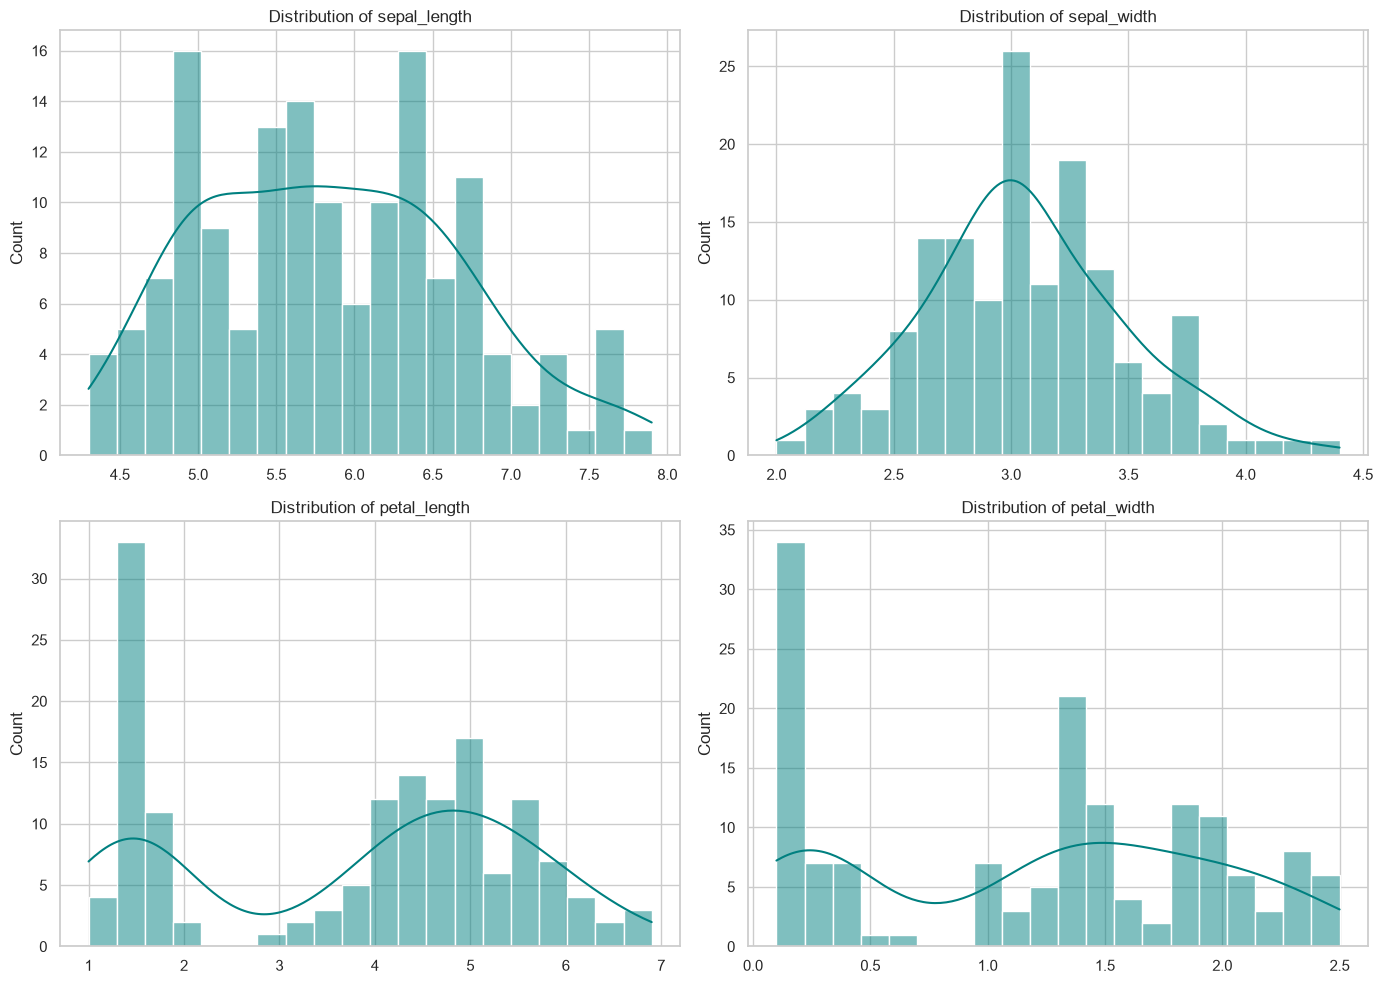

In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    
    sns.histplot(data=df, x=feature, kde=True, ax=axes[row, col], color="teal", bins=20)
    
    axes[row, col].set_title(f'Distribution of {feature}', fontsize=12)
    axes[row, col].set_xlabel('')

plt.tight_layout()
plt.show()

*** Nhận xét ***
- sepal_length và sepal_width có hình dạng phân phối khá đối xứng, hình chuông, gần với phân phối chuẩn
- petal_length và petal_width đều thể hình dạng phân phối nhiều đỉnh, bị tách đôi thành 2 cụm   


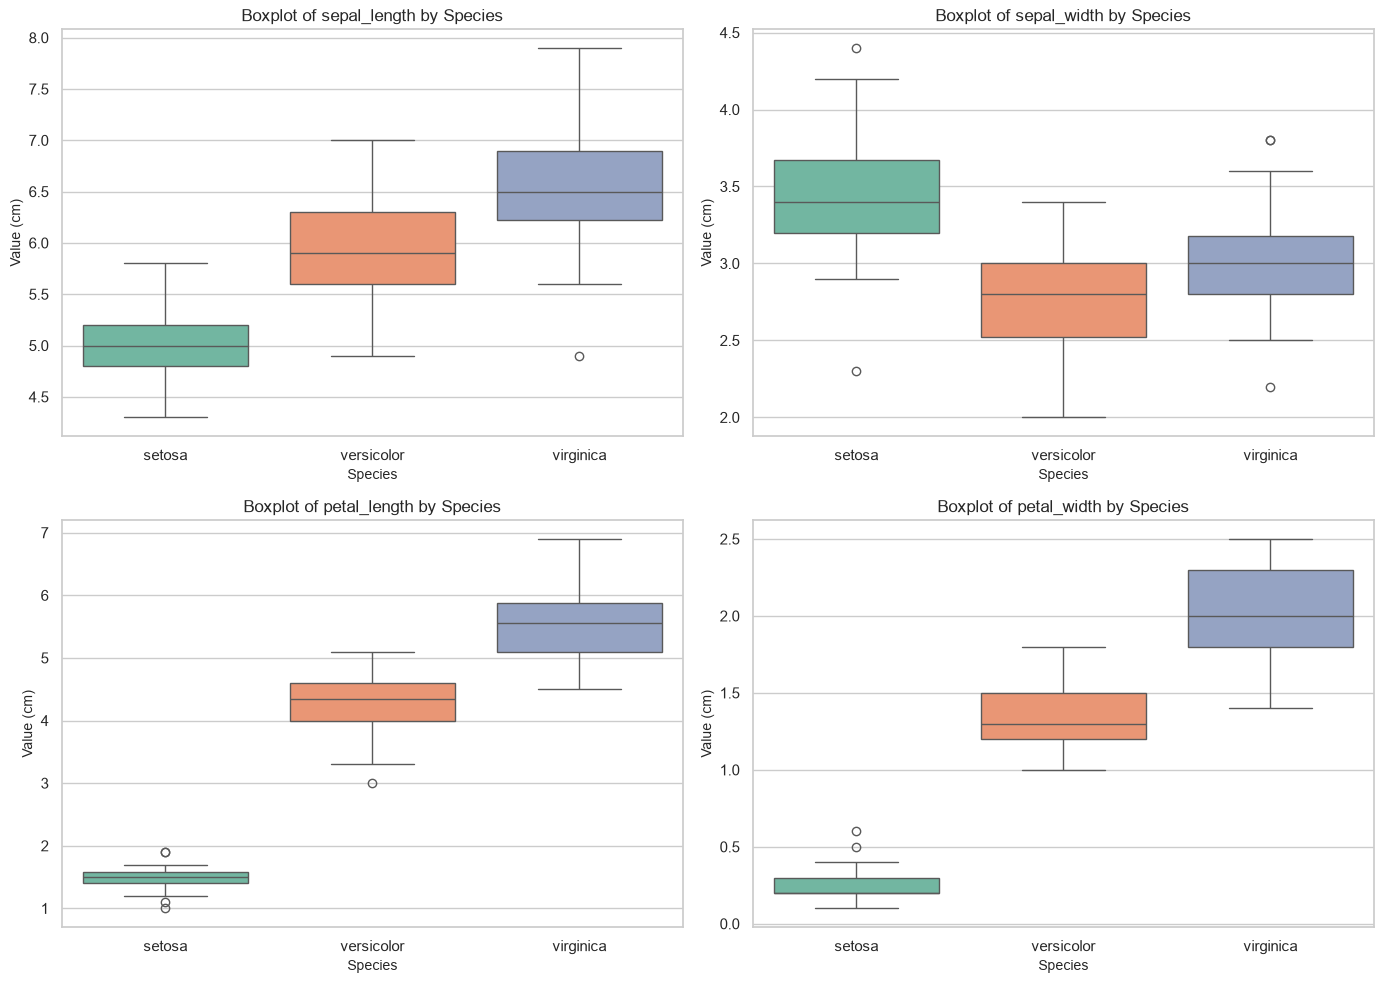

In [8]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2

    sns.boxplot(
        data=df, 
        x='species', 
        y=feature, 
        ax=axes[row, col], 
        hue='species', 
        palette="Set2", 
        legend=False
    )
        
    axes[row, col].set_title(f'Boxplot of {feature} by Species', fontsize=12)
    axes[row, col].set_xlabel('Species', fontsize=10)
    axes[row, col].set_ylabel('Value (cm)', fontsize=10)

plt.tight_layout()
plt.show()

*** Nhận xét ***
- Xét biến sepal_length và sepal_width: các hộp dữ liệu có sự chồng lấn lên nhau --> các đặc trưng này khó dùng để phân biệt các loài.
- Xét biến petal_length và petal_width: 
    + Loài setosa: hộp dữ liệu ở vị trí thấp và tách biệt so với 2 loài còn lại. Thân hộp hẹp --> phân phối của petal của setosa tập trung và đồng đều ở giá trị nhỏ.
    + Loài versicolor và virginica: phân phối ở vùng cao hơn, ít có sự chồng lấn dữ liệu nên vẫn phân biệt tương đối tốt.
- Boxplot cho thấy dữ liệu của setosa ít bị chồng lấn so với các nhóm khác, cho thấy setosa là loài có sự khác biệt nhất.
==> setosa là loài tách biệt rõ nhất nhờ đặc trưng petal, còn versicolor và virginica khó phân biệt hơn ở các biến sepal. Do đó petal_length và petal_width nên được ưu tiên làm đặc trưng chính để phân loại loài.

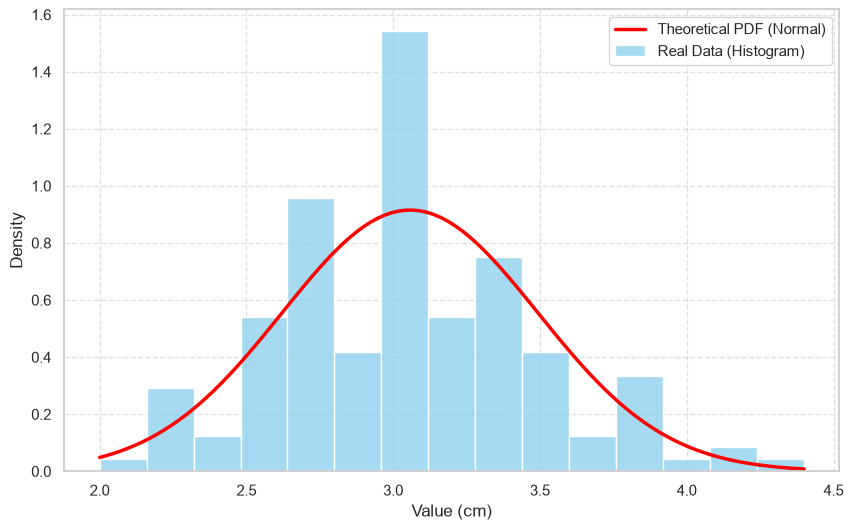

In [9]:
from scipy.stats import norm
chosen_feature = 'sepal_width'
data_real = df[chosen_feature]

mean_real = data_real.mean()
std_real = data_real.std()

data_simulated = np.random.normal(loc=mean_real, scale=std_real, size=len(data_real))

plt.figure(figsize=(10,6))

sns.histplot(data_real, kde=False, stat="density", color="skyblue", label="Real Data (Histogram)", bins=15)

x = np.linspace(data_real.min(), data_real.max(), 100)
plt.plot(x, norm.pdf(x, mean_real, std_real), color="red", linewidth=2.5, label="Theoretical PDF (Normal)")
plt.xlabel('Value (cm)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


*** Nhận xét ***
- Mức độ trùng khớp: đường Theoretical PDF khớp với phần lớn các cột Real Data, điểm đỉnh cao nhất của dữ liệu thực tế và đường lý thuyết đều tập trung xung quanh giá trị trung bình 3.0.
- Tuy nhiên tại đỉnh ~3.0 có độ chênh lệch giữa giá trị lý thuyết (~0.9) và giá trị thực tế (~1.5); một số cột cũng chưa hoàn toàn khớp với đường Theoretical PDF.
- Biến sepal_width của tập dữ liệu Iris có mức độ trùng khớp cao với phân phối chuẩn lý thuyết (đối xứng, hình chuông) --> đặc trưng này xấp xỉ quy luật của phân phối chuẩn.

PHẦN 3

In [10]:
covariance_matrix = df_numeric.cov()
correlation_matrix = df_numeric.corr()

print("Covariance matrix")
print(covariance_matrix.round(4))

print("----------------")

print("Correlation matrix")
print(correlation_matrix.round(4))


Covariance matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        0.6857      -0.0424        1.2743       0.5163
sepal_width        -0.0424       0.1900       -0.3297      -0.1216
petal_length        1.2743      -0.3297        3.1163       1.2956
petal_width         0.5163      -0.1216        1.2956       0.5810
----------------
Correlation matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length        1.0000      -0.1176        0.8718       0.8179
sepal_width        -0.1176       1.0000       -0.4284      -0.3661
petal_length        0.8718      -0.4284        1.0000       0.9629
petal_width         0.8179      -0.3661        0.9629       1.0000


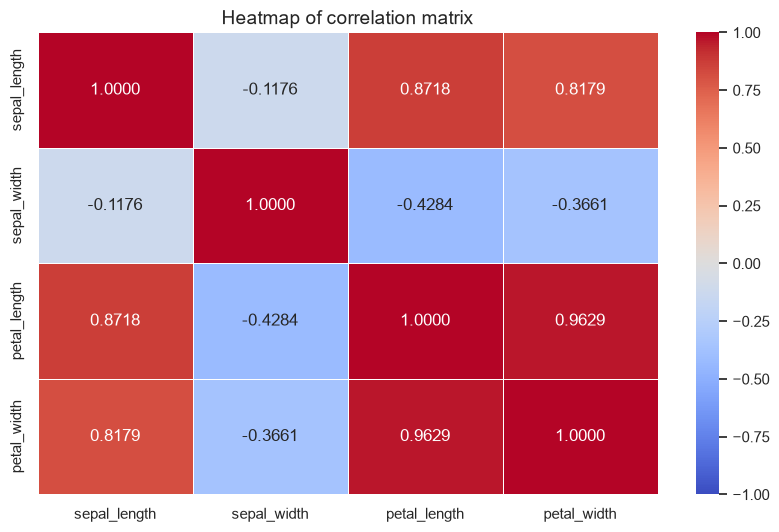

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Heatmap of correlation matrix', fontsize=14)
plt.show()

*** Nhận xét ***
- Cặp biến tương quan mạnh nhất: petal_length và petal_width với hệ số tương quan 0.9629.
- Tập dữ liệu này có dấu hiệu đa cộng tuyến khi độ lớn hệ số tương quan của các cặp dữ liệu > 0.8 --> có thể bỏ bớt một đặc trưng trong cặp pental vì gần như trùng thông tin.

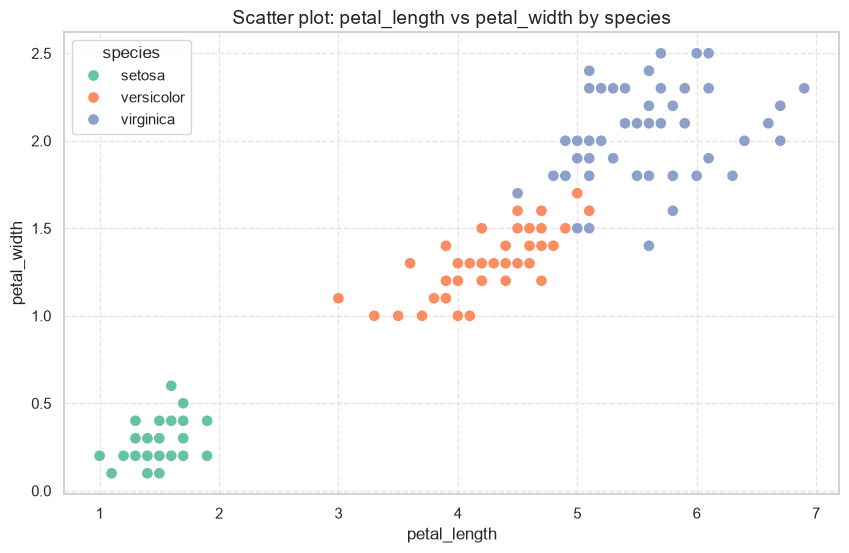

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', s=70)

plt.title('Scatter plot: petal_length vs petal_width by species', fontsize=14)
plt.xlabel('petal_length', fontsize=12)
plt.ylabel('petal_width', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

*** Nhận xét ***
- Các điểm trên biểu đồ có xu hương tập trung kéo dài thành 1 dải đi lên từ trái sang phải --> petal_length và petal_width có mối quan hệ tương quan thuận mạnh và các điểm phần lớn tập trung bên phải.
- Các điểm màu cũng phân tách thành các vùng rõ rệt.

PHẦN 4

In [13]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_pos = P_pos_givenB*P_B + P_pos_givenNB*(1-P_B)

P_B_given_pos = (P_pos_givenB*P_B)/P_pos

print(f"P_B_given_pos = {round(P_B_given_pos,4)}")

P_B_given_pos = 0.1667


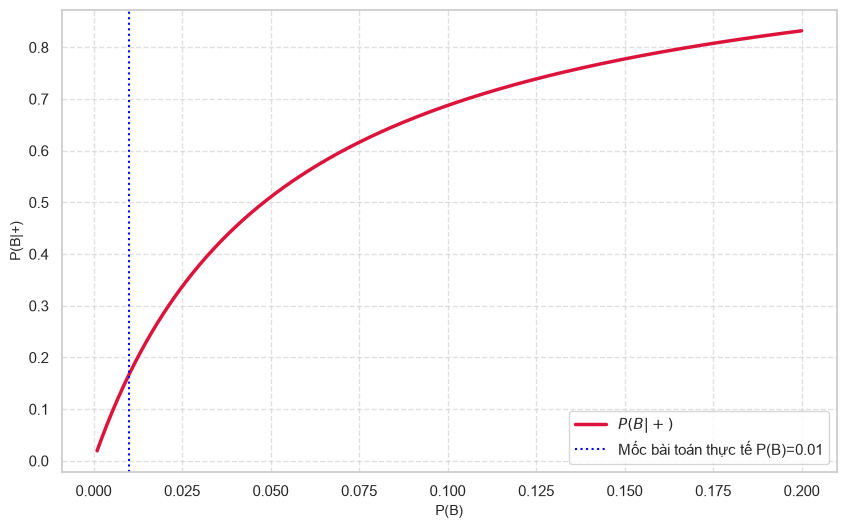

In [14]:
P_B_range = np.linspace(0.001, 0.2, 500)

P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_pos_range = P_pos_givenB * P_B_range + P_pos_givenNB * (1 - P_B_range)
P_B_given_pos_range = (P_pos_givenB * P_B_range) / P_pos_range

plt.figure(figsize=(10, 6))
plt.plot(P_B_range, P_B_given_pos_range, color='crimson', linewidth=2.5, label='$P(B|+)$')

plt.xlabel('P(B)', fontsize=10)
plt.ylabel('P(B|+)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=0.01, color='blue', linestyle=':', label='Mốc bài toán thực tế P(B)=0.01')
plt.legend()

plt.show()

*** Nhận xét ***
- Tại mốc tỉ lệ mắc bệnh thực tế P(B) = 0.01, dù xét nghiệm có độ nhạy cao P(+|B) = 0.99, nhưng xác suất một người thực sự mắc bệnh khi nhận kết quả dương tính P(B|+) chỉ 0.1667.
- Hiện tượng "phản trực giác" ở đây là người ta sẽ cho rằng với độ nhạy của xét nghiệm cao thì xác suất mắc bệnh khi dương tính cũng phải cao. Tuy nhiên, vì đây là bệnh hiếm, số lượng người không mắc bệnh chiếm phần lớn (99%), do đó, dù tỉ lệ sai sót dương tính giả là 5%, nhưng khi nhân với lượng người khoẻ mạnh thì số ca dương tính giả lớn hơn nhiều so với số ca dương tính thật.
- Đồ thị cho thấy khi tỉ lệ mắc bệnh tăng lên (bệnh không còn là hiếm), số ca dương tính giả giảm bớt, khiến xác suất P(B|+) tăng lên rất nhanh.

XÂY DỰNG BỘ LỌC SPAM THEO NAIVE BAYES

- Chọn 3 từ khoá: "miễn phí", "khuyến mãi", "trúng thưởng"
- Công thức Bayes áp dụng: P(spam|key1, key2, key3) = [P(key 1|spam) x P(key 2|spam) x P(key 3|spam) x P(spam)] / P(key1, key2, key 3)
- Mong muốn kết quả nhận được khi email càng chứa nhiều từ khoá thì xác suất là spam càng cao
- Giả sử tỉ lệ email spam trong hệ thống là 30%, email hợp lệ là 70%; các từ khoá xuất hiện 80% trong các email rác, xuất hiện 10% trong các email hợp lệ

In [15]:
P_spam = 0.3
P_nspam = 0.7

keywords = {
    "miễn phí": {"spam": 0.8, "nspam": 0.1},
    "khuyến mãi": {"spam": 0.8, "nspam": 0.1},
    "trúng thưởng": {"spam": 0.8, "nspam": 0.1}
}

def check(email_title):
    title_lower = email_title.lower()

    numerator_spam = P_spam
    numerator_nspam = P_nspam
    
    for key, prob in keywords.items():
        if key in title_lower:
            numerator_spam *= prob["spam"]
            numerator_nspam *= prob["nspam"]
        else:
            numerator_spam *= (1 - prob["spam"])
            numerator_nspam *= (1 - prob["nspam"])
            
    P_email = numerator_spam + numerator_nspam

    P_spam_given_email = numerator_spam / P_email
    return round(P_spam_given_email, 4)

emails = [
    {"title": "Chúc mừng bạn đã trúng thưởng"},                                   
    {"title": "Thông báo nhận giải thưởng trúng thưởng miễn phí và khuyến mãi"}, 
    {"title": "Lịch học tuần sau của lab"}                                        
]

for i, email in enumerate(emails, 1):
    prob = check(email["title"])
    status = "SPAM (Nguy hiểm)" if prob > 0.5 else "NOT SPAM (An toàn)"
    print(f"Email {i}: '{email['title']}'")
    print(f"  -> Xác suất là Spam = {prob * 100}% -> Phân loại: {status}\n")



Email 1: 'Chúc mừng bạn đã trúng thưởng'
  -> Xác suất là Spam = 14.48% -> Phân loại: NOT SPAM (An toàn)

Email 2: 'Thông báo nhận giải thưởng trúng thưởng miễn phí và khuyến mãi'
  -> Xác suất là Spam = 99.55000000000001% -> Phân loại: SPAM (Nguy hiểm)

Email 3: 'Lịch học tuần sau của lab'
  -> Xác suất là Spam = 0.47000000000000003% -> Phân loại: NOT SPAM (An toàn)

